# **Part I: Regression Task**

# Fuel Efficiency Prediction on the Auto MPG Dataset

This notebook analyzes a supervised regression problem using the Auto MPG dataset.  
The goal is to predict a vehicle's fuel efficiency (miles per gallon – MPG) based on several vehicle characteristics.

The analysis includes:

- Exploratory Data Analysis (EDA)
- Data preprocessing
- Linear Regression baseline
- Polynomial Regression with model complexity analysis
- K-Nearest Neighbors (KNN) regression
- Optimization behavior analysis
- Model comparison and final evaluation on a held-out test set

# Part 1: Regression on Auto MPG

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style("whitegrid")

## 1. Data Loading
In this part, we analyze the Auto MPG dataset in order to predict fuel efficiency, measured in miles per gallon (MPG), from structured vehicle attributes. We begin by loading the dataset and inspecting its basic structure before moving to exploratory analysis and model development.

In [2]:
import os
import numpy as np
import pandas as pd
from urllib.request import urlopen

column_names = [
    "mpg", "cylinders", "displacement", "horsepower",
    "weight", "acceleration", "model_year", "origin"
]

local_path = "auto-mpg.data"
url = "http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

if os.path.exists(local_path):
    with open(local_path, "r", encoding="utf-8") as f:
        lines = f.readlines()
else:
    with urlopen(url) as response:
        lines = [line.decode("utf-8") for line in response.readlines()]

rows = []
for line in lines:
    parts = line.strip().split(maxsplit=8)
    rows.append(parts[:8])

df = pd.DataFrame(rows, columns=column_names)
df = df.replace("?", np.nan)

for col in column_names:
    df[col] = pd.to_numeric(df[col])

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


### Initial Inspection
We first inspect the dataset dimensions, variable types, and a small sample of rows in order to verify that the data was loaded correctly and to understand its overall structure.

In [3]:
print(df.shape)
df.info()
df.isnull().sum()

(398, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
dtypes: float64(5), int64(3)
memory usage: 25.0 KB


,0
mpg,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model_year,0
origin,0


## 2. Exploratory Data Analysis
Before training any regression models, we perform an exploratory analysis of the dataset.  
This step helps us understand the structure of the data, identify missing values, and examine the relationships between the features and the target variable (MPG).

We analyze:

- Missing values in the dataset
- The distribution of the target variable
- Correlations between features
- Relationships between individual features and MPG


### Handling Missing Values

We first inspect missing values across the dataset.  
The missing-value check shows that missing entries appear in the `horsepower` feature.  
The actual imputation step is performed later during preprocessing.

In [4]:
df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model_year,0
origin,0


### Missing-Value Treatment

The missing values in `horsepower` will be handled during preprocessing.  
To avoid data leakage, imputation is performed after splitting the data, using the median computed from the training set only.

### Distribution of the Target Variable
Understanding the distribution of the target variable (MPG) is important for regression modeling.  
This plot helps identify skewness, outliers, or other characteristics that may influence model performance.

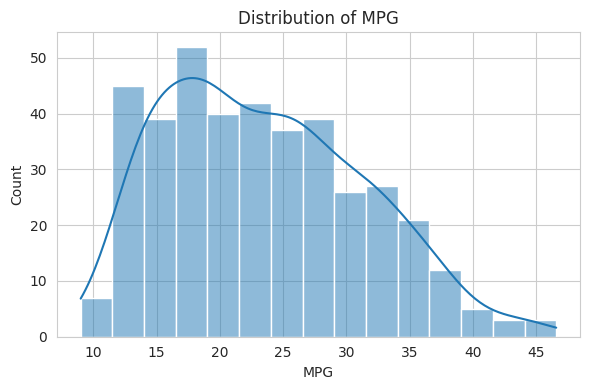

In [5]:
plt.figure(figsize=(6, 4))
sns.histplot(df["mpg"], bins=15, kde=True)
plt.title("Distribution of MPG")
plt.xlabel("MPG")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Most MPG values are concentrated roughly between 15 and 30, with a slight right tail toward higher fuel-efficiency values.  
This suggests that extremely high MPG vehicles are less common, while most cars in the dataset fall within a moderate fuel-efficiency range.

### Feature-Target Relationships

To better understand how the predictors relate to fuel efficiency, we visualize the relationship between each feature and the target variable (MPG).  
Continuous variables are shown using scatter plots, while discrete variables are presented using boxplots.

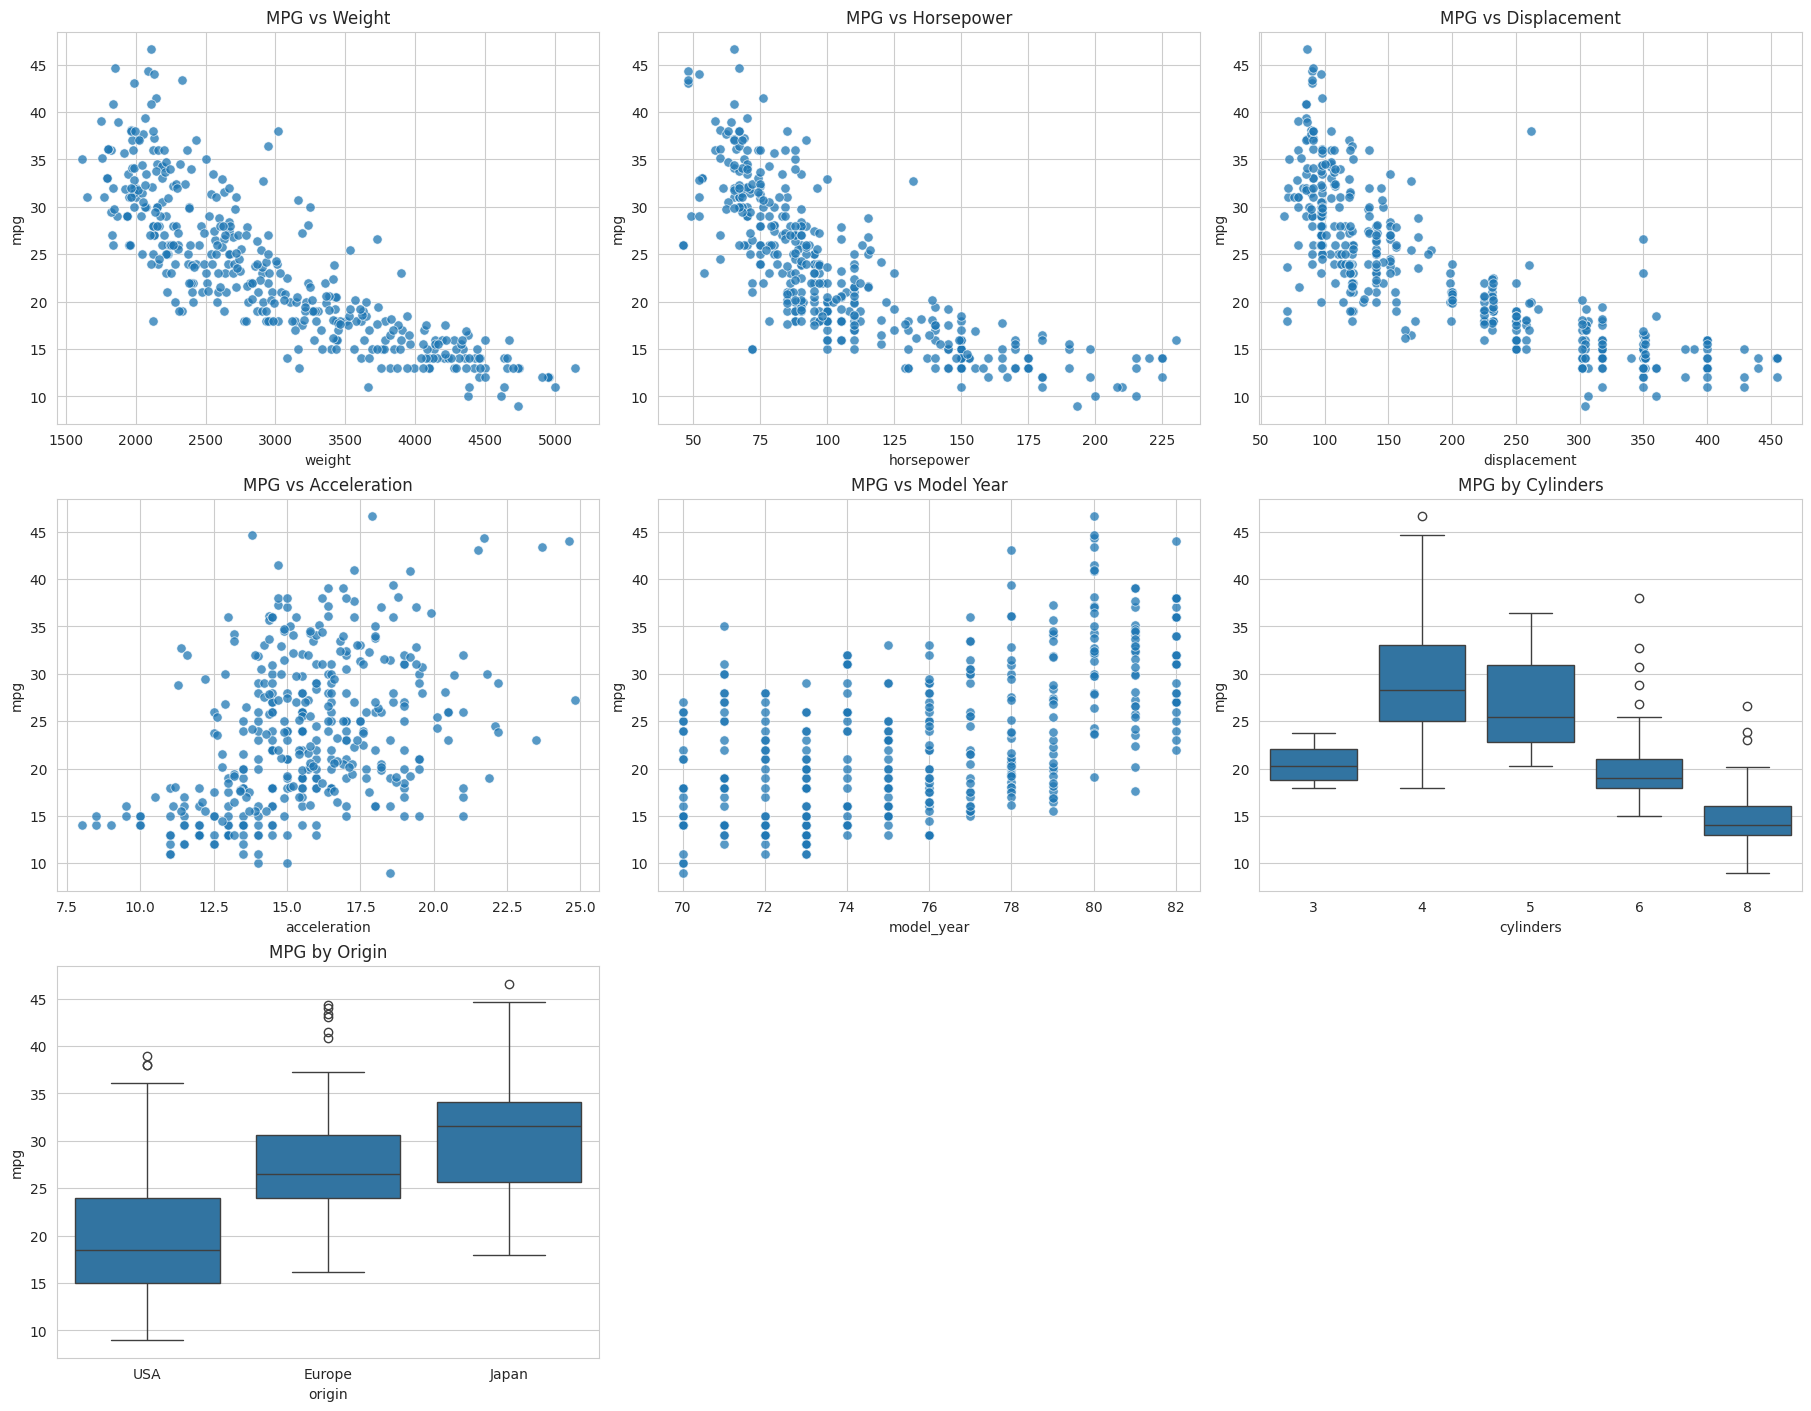

In [6]:
df_plot = df.copy()
df_plot["origin"] = df_plot["origin"].map({1: "USA", 2: "Europe", 3: "Japan"})

fig, axes = plt.subplots(3, 3, figsize=(18, 14), constrained_layout=True)
axes = axes.flatten()

sns.scatterplot(data=df_plot, x="weight", y="mpg", alpha=0.75, s=45, ax=axes[0])
axes[0].set_title("MPG vs Weight")

sns.scatterplot(data=df_plot, x="horsepower", y="mpg", alpha=0.75, s=45, ax=axes[1])
axes[1].set_title("MPG vs Horsepower")

sns.scatterplot(data=df_plot, x="displacement", y="mpg", alpha=0.75, s=45, ax=axes[2])
axes[2].set_title("MPG vs Displacement")

sns.scatterplot(data=df_plot, x="acceleration", y="mpg", alpha=0.75, s=45, ax=axes[3])
axes[3].set_title("MPG vs Acceleration")

sns.scatterplot(data=df_plot, x="model_year", y="mpg", alpha=0.75, s=45, ax=axes[4])
axes[4].set_title("MPG vs Model Year")

sns.boxplot(data=df_plot, x="cylinders", y="mpg", ax=axes[5])
axes[5].set_title("MPG by Cylinders")

sns.boxplot(
    data=df_plot,
    x="origin",
    y="mpg",
    order=["USA", "Europe", "Japan"],
    ax=axes[6]
)
axes[6].set_title("MPG by Origin")

axes[7].axis("off")
axes[8].axis("off")

plt.show()

The plots show clear negative relationships between MPG and features such as `weight`, `horsepower`, and `displacement`, indicating that larger and more powerful cars tend to be less fuel-efficient.  
In contrast, `model_year` shows a positive association with MPG, suggesting that newer cars in the dataset tend to achieve better fuel efficiency.

### Feature Correlations
The correlation matrix helps us examine relationships among the numerical variables in the dataset.  
In particular, it highlights which predictors are strongly associated with MPG and which features are strongly related to one another.

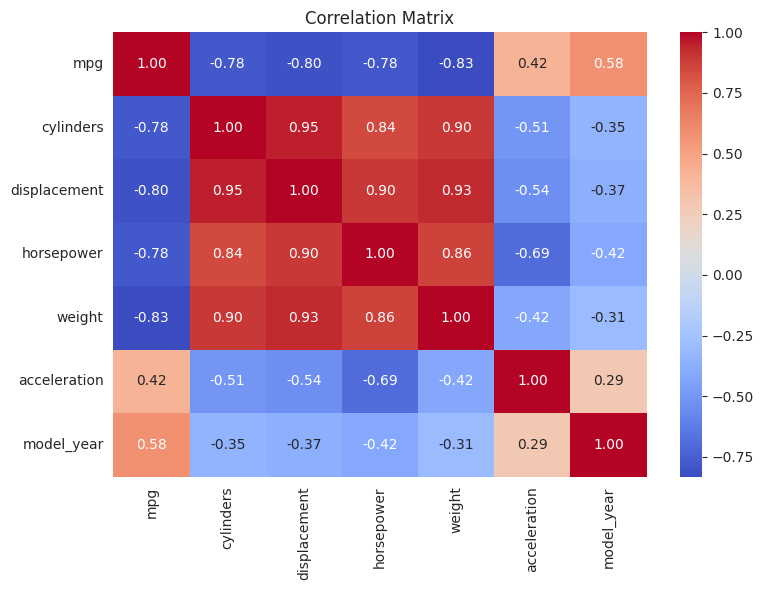

In [7]:
corr_cols = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year"]

plt.figure(figsize=(8, 6))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

The correlation matrix supports the visual findings from the previous plots.  
In particular, `weight`, `displacement`, and `horsepower` are strongly negatively correlated with MPG, while `model_year` is positively correlated with MPG.  
Several predictors are also strongly correlated with one another, which suggests some degree of multicollinearity in the dataset.

## 3. Data Preprocessing
Before training the models, the dataset must be prepared carefully.

Key preprocessing steps include:

- Encoding the categorical variable `origin`
- Splitting the dataset into training, validation, and test sets
- Imputing missing values using the training set only
- Standardizing the features for models that are sensitive to scale

The test set is reserved strictly for the final evaluation and is **not used during model selection or hyperparameter tuning**.

The analysis uses the structured predictors specified for the task, while the textual car name field is not included in the modeling pipeline.

In [8]:
df = pd.get_dummies(df, columns=["origin"], drop_first=True, dtype=int)
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_2,origin_3
0,18.0,8,307.0,130.0,3504.0,12.0,70,0,0
1,15.0,8,350.0,165.0,3693.0,11.5,70,0,0
2,18.0,8,318.0,150.0,3436.0,11.0,70,0,0
3,16.0,8,304.0,150.0,3433.0,12.0,70,0,0
4,17.0,8,302.0,140.0,3449.0,10.5,70,0,0


### Defining Features and Target

We define the feature matrix `X` and the target vector `y`, where `mpg` is the response variable and all remaining columns are used as predictors.

In [9]:
X = df.drop(columns=["mpg"])
y = df["mpg"]

feature_names = X.columns

### Train, Validation, and Test Split

We split the dataset into training, validation, and test sets.  
The validation set is used for model selection and hyperparameter tuning, while the test set is reserved strictly for the final evaluation.

In [10]:
# Split into train / validation / test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)

X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (238, 8)
Validation shape: (80, 8)
Test shape: (80, 8)


### Training-Based Imputation

Missing values in `horsepower` are imputed using the median computed from the training set only.  
The same value is then applied to the validation and test sets.

In [11]:
hp_median = X_train["horsepower"].median()

X_train["horsepower"] = X_train["horsepower"].fillna(hp_median)
X_val["horsepower"] = X_val["horsepower"].fillna(hp_median)
X_test["horsepower"] = X_test["horsepower"].fillna(hp_median)

### Standardization
The predictors are standardized using the training set only, meaning that each feature is centered and scaled based on the training data.  
This is especially important for distance-based models such as KNN, and it also ensures a consistent feature scale for the linear and polynomial models.

In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

## 4. Linear Regression Baseline
We begin with a simple **linear regression model**, which serves as the baseline for comparison with more flexible models.

As the simplest reasonable approach to the problem, this model assumes a linear relationship between the input features and the target variable.

In [13]:
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

y_val_pred_linear = linear_model.predict(X_val_scaled)

linear_val_mse = mean_squared_error(y_val, y_val_pred_linear)
linear_val_rmse = np.sqrt(linear_val_mse)
linear_val_mae = mean_absolute_error(y_val, y_val_pred_linear)
linear_val_r2 = r2_score(y_val, y_val_pred_linear)

print("Linear Regression Validation Metrics")
print("MSE:", linear_val_mse)
print("RMSE:", linear_val_rmse)
print("MAE:", linear_val_mae)
print("R2:", linear_val_r2)

Linear Regression Validation Metrics
MSE: 15.305067072819082
RMSE: 3.9121691007443786
MAE: 2.942080894021321
R2: 0.7939742977878181


## 5. Model Evaluation
We now evaluate the linear regression model visually in addition to the numerical metrics reported above.

### Prediction Vs. Ground Truth
This plot compares the predicted MPG values with the true MPG values on the validation set.  
Points closer to the diagonal reference line indicate more accurate predictions.

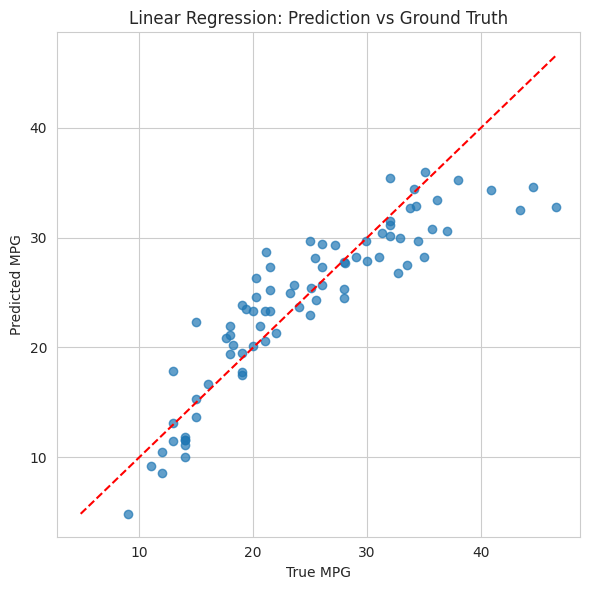

In [14]:
plt.figure(figsize=(6, 6))

plt.scatter(y_val, y_val_pred_linear, alpha=0.7)

min_val = min(y_val.min(), y_val_pred_linear.min())
max_val = max(y_val.max(), y_val_pred_linear.max())

plt.plot([min_val, max_val], [min_val, max_val], "r--")

plt.xlabel("True MPG")
plt.ylabel("Predicted MPG")
plt.title("Linear Regression: Prediction vs Ground Truth")
plt.tight_layout()
plt.show()

### Residual Analysis

The residual plot provides another way to assess the adequacy of the linear model.  
If the residuals are randomly scattered around zero, the linearity assumption is more plausible.  
In our case, the residuals are centered around zero overall, but the spread is not completely uniform, suggesting that the linear model does not capture all patterns in the data equally well.

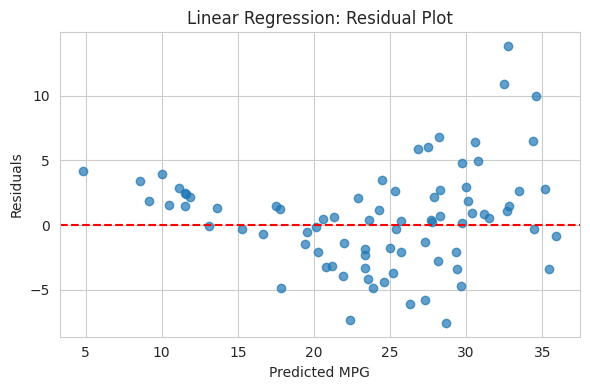

In [15]:
linear_residuals = y_val - y_val_pred_linear

plt.figure(figsize=(6, 4))
plt.scatter(y_val_pred_linear, linear_residuals, alpha=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted MPG")
plt.ylabel("Residuals")
plt.title("Linear Regression: Residual Plot")
plt.tight_layout()
plt.show()

### Coefficient Inspection

Since the predictors were standardized before fitting the model, the learned coefficients can be compared on a common scale.  
This plot provides an additional view of how the linear model weights the different input features, although the coefficients should be interpreted with some caution because several predictors are strongly correlated.

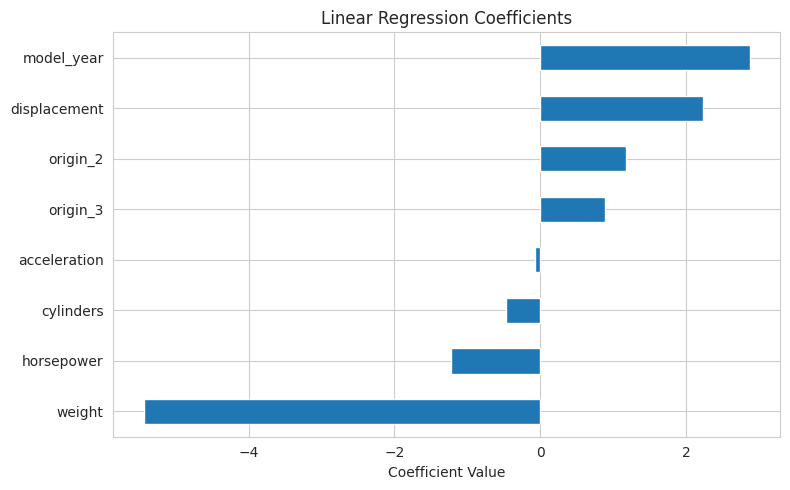

In [16]:
coefficients = pd.Series(linear_model.coef_, index=feature_names)

plt.figure(figsize=(8, 5))
coefficients.sort_values().plot(kind="barh")
plt.title("Linear Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.show()

# 6. Polynomial Regression
To increase model flexibility, we extend the linear regression model using **polynomial features**.

We evaluate models with different polynomial degrees and examine how increasing model complexity affects both training and validation error.

In [17]:
degrees = range(1, 8)

poly_train_errors = []
poly_val_errors = []

for d in degrees:
    poly_candidate = Pipeline([
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        ("linreg", LinearRegression())
    ])

    poly_candidate.fit(X_train_scaled, y_train)

    y_train_pred = poly_candidate.predict(X_train_scaled)
    y_val_pred = poly_candidate.predict(X_val_scaled)

    poly_train_errors.append(mean_squared_error(y_train, y_train_pred))
    poly_val_errors.append(mean_squared_error(y_val, y_val_pred))

### Model Complexity Curve

This plot shows how training and validation MSE vary as the polynomial degree increases.

It helps us detect:

- **Underfitting** at low polynomial degrees, where the model is too restrictive to represent the relationship between the features and MPG
- **Overfitting** at high polynomial degrees, where the model becomes overly flexible and loses generalization ability

In our results, degree 2 gives the best validation performance, while higher degrees drastically reduce the training error but lead to much worse validation error, indicating severe overfitting.

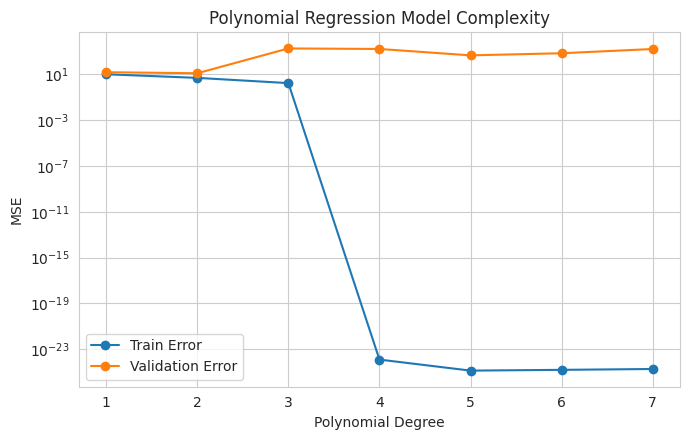

In [18]:
plt.figure(figsize=(7, 4.5))
plt.plot(degrees, poly_train_errors, marker="o", label="Train Error")
plt.plot(degrees, poly_val_errors, marker="o", label="Validation Error")
plt.xlabel("Polynomial Degree")
plt.ylabel("MSE")
plt.title("Polynomial Regression Model Complexity")
plt.xticks(list(degrees))
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.show()

### Selecting the Polynomial Degree

Based on the validation MSE, degree 2 is selected as the best polynomial configuration.  
We then fit the final polynomial regression model with this degree and evaluate it on the validation set.

In [19]:
best_degree = degrees[np.argmin(poly_val_errors)]
print("Best polynomial degree:", best_degree)

poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=best_degree, include_bias=False)),
    ("linreg", LinearRegression())
])

poly_model.fit(X_train_scaled, y_train)

y_val_pred_poly = poly_model.predict(X_val_scaled)

poly_val_mse = mean_squared_error(y_val, y_val_pred_poly)
poly_val_rmse = np.sqrt(poly_val_mse)
poly_val_mae = mean_absolute_error(y_val, y_val_pred_poly)
poly_val_r2 = r2_score(y_val, y_val_pred_poly)

print("Polynomial Regression Validation Metrics")
print("MSE:", poly_val_mse)
print("RMSE:", poly_val_rmse)
print("MAE:", poly_val_mae)
print("R2:", poly_val_r2)


Best polynomial degree: 2
Polynomial Regression Validation Metrics
MSE: 12.466273734335951
RMSE: 3.5307610701286416
MAE: 2.497431221461116
R2: 0.8321880728868464


### Prediction Vs. Ground Truth for Polynomial Regression
This plot compares the predicted MPG values of the selected polynomial model with the true MPG values on the validation set.  
Points closer to the diagonal reference line indicate more accurate predictions.

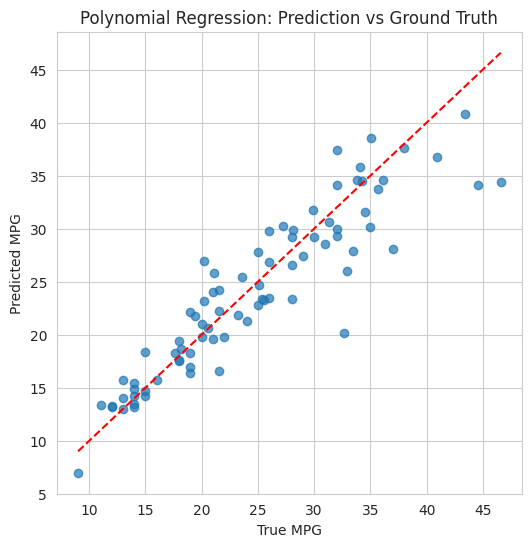

In [20]:
plt.figure(figsize=(6,6))
plt.scatter(y_val, y_val_pred_poly, alpha=0.7)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], "r--")
plt.xlabel("True MPG")
plt.ylabel("Predicted MPG")
plt.title("Polynomial Regression: Prediction vs Ground Truth")
plt.show()

# 7. KNN Regression
KNN regression is a **non-parametric model** that predicts the target value based on nearby observations in the feature space.  
Its behavior depends strongly on the choice of **k**, which controls how local or smooth the predictions are.

We evaluate different values of **k** and select the one that achieves the best validation performance.

In [21]:
k_values = range(1, 31)

knn_train_errors = []
knn_val_errors = []

for k in k_values:
    knn_candidate = KNeighborsRegressor(n_neighbors=k)
    knn_candidate.fit(X_train_scaled, y_train)

    y_train_pred = knn_candidate.predict(X_train_scaled)
    y_val_pred = knn_candidate.predict(X_val_scaled)

    knn_train_errors.append(mean_squared_error(y_train, y_train_pred))
    knn_val_errors.append(mean_squared_error(y_val, y_val_pred))

### Selecting k

We compare training and validation MSE across different values of `k`.  
Small values of `k` make the model more flexible and more sensitive to local noise, while larger values produce smoother predictions but may increase bias.

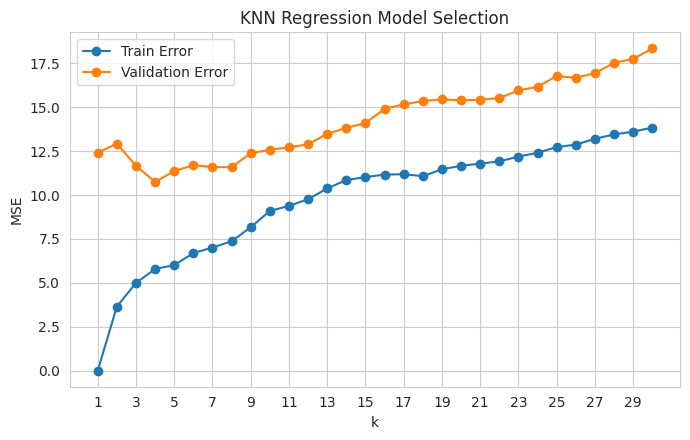

In [22]:
plt.figure(figsize=(7, 4.5))
plt.plot(k_values, knn_train_errors, marker="o", label="Train Error")
plt.plot(k_values, knn_val_errors, marker="o", label="Validation Error")
plt.xlabel("k")
plt.ylabel("MSE")
plt.title("KNN Regression Model Selection")
plt.xticks(range(1, 31, 2))
plt.legend()
plt.tight_layout()
plt.show()

### Final KNN Configuration

Based on the validation MSE, the best value is `k = 4`.  
We now fit the final KNN model with this value and evaluate its performance on the validation set.

In [23]:
best_k = k_values[np.argmin(knn_val_errors)]
print("Best k:", best_k)

knn_model = KNeighborsRegressor(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)

y_val_pred_knn = knn_model.predict(X_val_scaled)

knn_val_mse = mean_squared_error(y_val, y_val_pred_knn)
knn_val_rmse = np.sqrt(knn_val_mse)
knn_val_mae = mean_absolute_error(y_val, y_val_pred_knn)
knn_val_r2 = r2_score(y_val, y_val_pred_knn)

print("KNN Regression Validation Metrics")
print("MSE:", knn_val_mse)
print("RMSE:", knn_val_rmse)
print("MAE:", knn_val_mae)
print("R2:", knn_val_r2)

Best k: 4
KNN Regression Validation Metrics
MSE: 10.751296875
RMSE: 3.278917027769992
MAE: 2.40125
R2: 0.8552738463788048


### Prediction Vs. Ground Truth for KNN
This plot compares the predicted MPG values of the selected KNN model with the true MPG values on the validation set.  
Points closer to the diagonal reference line indicate more accurate predictions.




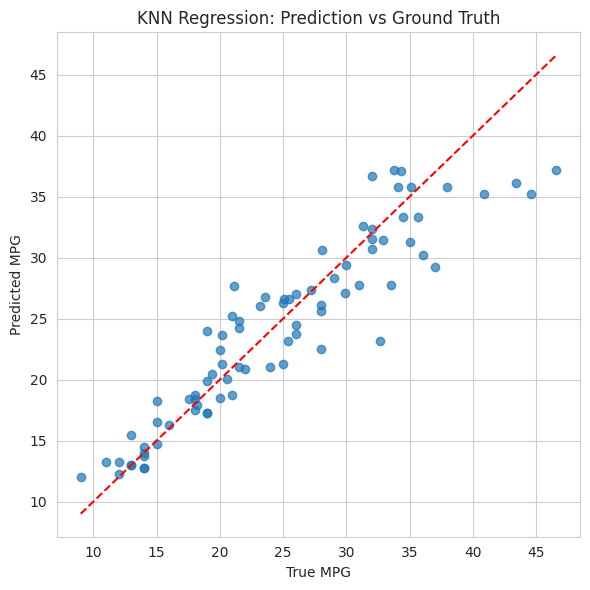

In [24]:
plt.figure(figsize=(6, 6))

plt.scatter(y_val, y_val_pred_knn, alpha=0.7)

min_val = min(y_val.min(), y_val_pred_knn.min())
max_val = max(y_val.max(), y_val_pred_knn.max())

plt.plot([min_val, max_val], [min_val, max_val], "r--")

plt.xlabel("True MPG")
plt.ylabel("Predicted MPG")
plt.title("KNN Regression: Prediction vs Ground Truth")
plt.tight_layout()
plt.show()

KNN can outperform parametric models when the relationship between the predictors and the target is non-linear and local patterns in the data are informative.  
However, it may be less suitable when interpretability is important or when fast inference is required, since its predictions depend directly on the training data.

## 8. Optimization Behavior
In this section, we analyze the behavior of different optimization strategies when minimizing the same regression objective.

Specifically, we compare:

- Batch Gradient Descent
- Mini-Batch Gradient Descent

We track training and validation MSE across epochs in order to compare convergence speed, stability, and generalization behavior.

In [25]:
# prepare numpy arrays
X_train_opt = np.array(X_train_scaled)
X_val_opt = np.array(X_val_scaled)

y_train_opt = np.array(y_train)
y_val_opt = np.array(y_val)

# add bias column manually
X_train_bias = np.c_[np.ones((X_train_opt.shape[0], 1)), X_train_opt]
X_val_bias = np.c_[np.ones((X_val_opt.shape[0], 1)), X_val_opt]


def mse_loss(X, y, w):
    y_pred = X @ w
    return np.mean((y - y_pred) ** 2)


def batch_gradient_descent(X_train, y_train, X_val, y_val, lr=0.01, epochs=200):
    n_samples, n_features = X_train.shape
    w = np.zeros(n_features)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        y_pred = X_train @ w
        gradient = (2 / n_samples) * X_train.T @ (y_pred - y_train)
        w -= lr * gradient

        train_losses.append(mse_loss(X_train, y_train, w))
        val_losses.append(mse_loss(X_val, y_val, w))

    return w, train_losses, val_losses


def mini_batch_gradient_descent(X_train, y_train, X_val, y_val, lr=0.01, epochs=200, batch_size=32, random_state=42):
    rng = np.random.default_rng(random_state)
    n_samples, n_features = X_train.shape
    w = np.zeros(n_features)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        indices = rng.permutation(n_samples)
        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]

        for start in range(0, n_samples, batch_size):
            end = start + batch_size
            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            y_pred_batch = X_batch @ w
            gradient = (2 / len(X_batch)) * X_batch.T @ (y_pred_batch - y_batch)
            w -= lr * gradient

        train_losses.append(mse_loss(X_train, y_train, w))
        val_losses.append(mse_loss(X_val, y_val, w))

    return w, train_losses, val_losses

In [26]:
epochs = 200
learning_rate = 0.01

w_batch, batch_train_losses, batch_val_losses = batch_gradient_descent(
    X_train_bias, y_train_opt,
    X_val_bias, y_val_opt,
    lr=learning_rate,
    epochs=epochs
)

w_mini, mini_train_losses, mini_val_losses = mini_batch_gradient_descent(
    X_train_bias, y_train_opt,
    X_val_bias, y_val_opt,
    lr=learning_rate,
    epochs=epochs,
    batch_size=32,
    random_state=42
)

### Optimization Curves

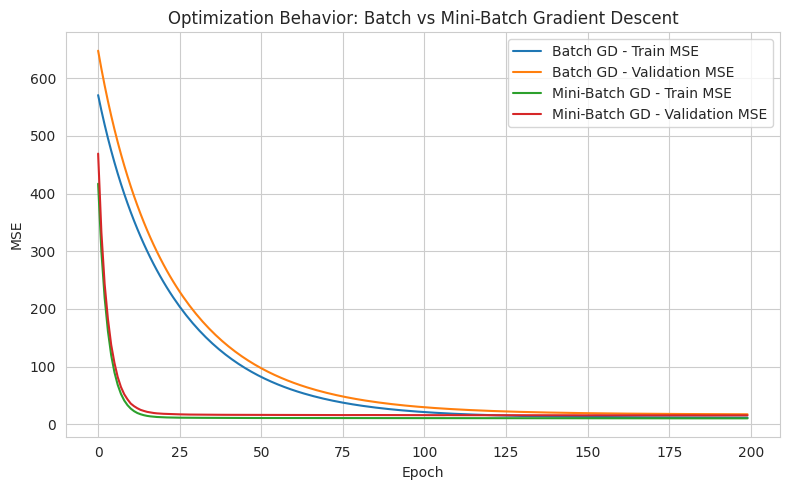

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(batch_train_losses, label="Batch GD - Train MSE")
plt.plot(batch_val_losses, label="Batch GD - Validation MSE")

plt.plot(mini_train_losses, label="Mini-Batch GD - Train MSE")
plt.plot(mini_val_losses, label="Mini-Batch GD - Validation MSE")

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Optimization Behavior: Batch vs Mini-Batch Gradient Descent")
plt.legend()
plt.tight_layout()
plt.show()

The batch gradient descent curves decrease smoothly across epochs, reflecting the fact that each update is computed using the full training set.  
The mini-batch method converges much faster in the early stages and reaches a lower loss more quickly in this experiment.  
Although mini-batch updates are based on smaller subsets of the data, the epoch-level curves remain fairly stable here, while still showing the practical efficiency advantage of mini-batch optimization.

In [28]:
print("Final losses after optimization:\n")

print("Batch Gradient Descent")
print("Train Loss:", batch_train_losses[-1])
print("Validation Loss:", batch_val_losses[-1])

print("\nMini-Batch Gradient Descent")
print("Train Loss:", mini_train_losses[-1])
print("Validation Loss:", mini_val_losses[-1])

Final losses after optimization:

Batch Gradient Descent
Train Loss: 11.467096541179284
Validation Loss: 17.287687446470205

Mini-Batch Gradient Descent
Train Loss: 10.250700085079677
Validation Loss: 15.481444990944723


### Final Loss Comparison
The table below summarizes the final training and validation losses obtained by the two optimization methods after 200 epochs.

In [29]:
opt_results = pd.DataFrame({
    "Method": ["Batch Gradient Descent", "Mini-Batch Gradient Descent"],
    "Final Train Loss": [batch_train_losses[-1], mini_train_losses[-1]],
    "Final Validation Loss": [batch_val_losses[-1], mini_val_losses[-1]]
})

opt_results

,Method,Final Train Loss,Final Validation Loss
0,Batch Gradient Descent,11.467097,17.287687
1,Mini-Batch Gradient Descent,10.250700,15.481445


## Model Comparison

Finally, we compare the performance of the three regression approaches:

- Linear Regression
- Polynomial Regression
- KNN Regression

Model selection is based on **validation performance**.  
The final selected model is then evaluated on the **test set**, which has not been used during model selection or hyperparameter tuning.

In [30]:
results_df = pd.DataFrame({
    "Model": ["Linear Regression", "Polynomial Regression", "KNN Regression"],
    "MSE": [linear_val_mse, poly_val_mse, knn_val_mse],
    "RMSE": [linear_val_rmse, poly_val_rmse, knn_val_rmse],
    "MAE": [linear_val_mae, poly_val_mae, knn_val_mae],
    "R2": [linear_val_r2, poly_val_r2, knn_val_r2]
})

results_df = results_df.sort_values(by="RMSE")
results_df

,Model,MSE,RMSE,MAE,R2
2,KNN Regression,10.751297,3.278917,2.401250,0.855274
1,Polynomial Regression,12.466274,3.530761,2.497431,0.832188
0,Linear Regression,15.305067,3.912169,2.942081,0.793974


The comparison shows that **KNN Regression** achieves the best validation performance across all reported metrics.  
**Polynomial Regression** improves over the linear baseline, suggesting that the relationship between the predictors and MPG is not purely linear.  
At the same time, **Linear Regression** remains the simplest and most interpretable model, although it provides the weakest predictive performance among the three candidates.

# 9. Choosing the Final Model

Based on the validation comparison, we now select the final regression model.  
At this stage, the test set remains untouched and is used only for the final evaluation.

In [31]:
best_model_name = results_df.iloc[0]["Model"]
print("Selected final model based on validation:", best_model_name)

Selected final model based on validation: KNN Regression


# 10. Retraining on the Combined Training and Validation Sets

After selecting the best model based on validation performance, we retrain it on the combined training and validation data in order to use all available development data before the final test evaluation.

### Final Test Evaluation
We then evaluate the selected final model on the held-out test set, which was not used during model selection.

In [32]:
# Recreate the original development/test split
X_temp_raw, X_test_raw, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Use all development data: train + validation
X_train_full_df = X_temp_raw.copy()
X_test_final_df = X_test_raw.copy()
y_train_full = y_temp.copy()

# Impute missing values using the combined development set only
hp_median_full = X_train_full_df["horsepower"].median()

X_train_full_df["horsepower"] = X_train_full_df["horsepower"].fillna(hp_median_full)
X_test_final_df["horsepower"] = X_test_final_df["horsepower"].fillna(hp_median_full)

# Standardize using the combined development set only
final_scaler = StandardScaler()
X_train_full_scaled = final_scaler.fit_transform(X_train_full_df)
X_test_final_scaled = final_scaler.transform(X_test_final_df)

# Refit the selected final model
if best_model_name == "Linear Regression":
    final_model = LinearRegression()

elif best_model_name == "Polynomial Regression":
    final_model = Pipeline([
        ("poly", PolynomialFeatures(degree=best_degree, include_bias=False)),
        ("linreg", LinearRegression())
    ])

else:
    final_model = KNeighborsRegressor(n_neighbors=best_k)

final_model.fit(X_train_full_scaled, y_train_full)

y_test_pred = final_model.predict(X_test_final_scaled)

test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Final Test Metrics")
print("MSE:", test_mse)
print("RMSE:", test_rmse)
print("MAE:", test_mae)
print("R2:", test_r2)

Final Test Metrics
MSE: 5.366015625
RMSE: 2.316466193364367
MAE: 1.9162500000000002
R2: 0.9001976837086236


### Final Prediction Vs. Ground Truth


This plot compares the predicted MPG values of the selected final KNN model with the true MPG values on the held-out test set.  
Points closer to the diagonal reference line indicate more accurate predictions.

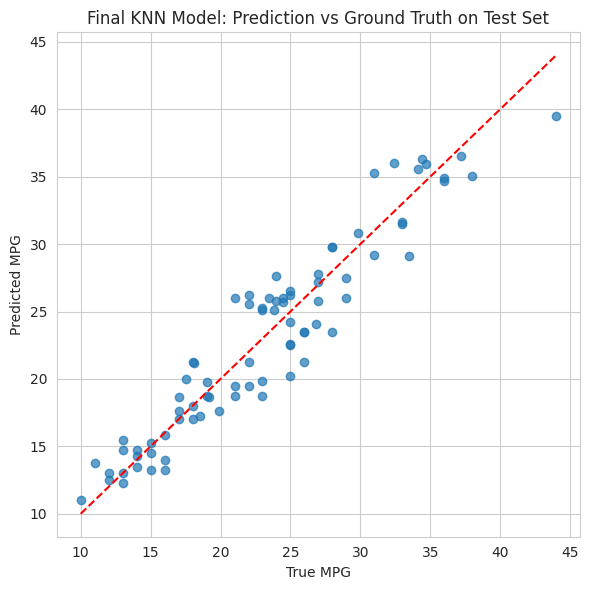

In [33]:
plt.figure(figsize=(6, 6))

plt.scatter(y_test, y_test_pred, alpha=0.7)

min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], "r--")

plt.xlabel("True MPG")
plt.ylabel("Predicted MPG")
plt.title("Final KNN Model: Prediction vs Ground Truth on Test Set")
plt.tight_layout()
plt.show()

The predictions on the held-out test set lie relatively close to the diagonal reference line, indicating good generalization performance of the selected final model.  
Although some prediction error remains, particularly for higher MPG values, the overall fit is strong and consistent with the reported test metrics.